In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#import minmaxscaler
from sklearn.preprocessing import MinMaxScaler
#import svr
from sklearn.svm import SVR
#import pipelines
from sklearn.pipeline import make_pipeline


In [58]:
def load_data(path):
    df=pd.read_csv(path)
    df["TEST_DATE"] = pd.to_datetime(df["TEST_DATE"])
    df = df.sort_values("TEST_DATE").dropna(subset=["OIL"]).reset_index(drop=True)
    df = df[df["OIL"] > 0].reset_index(drop=True)
    return df

In [59]:
def visualize_data(df):
    plt.figure(figsize=(12, 6))
    sns.lineplot(x="TEST_DATE", y="OIL", data=df)
    plt.title("Oil Production Over Time")
    plt.xlabel("Date")
    plt.ylabel("Oil Production")
    plt.show()

In [60]:
def create_dataset(series, time_steps=30):
    Xs, ys, indices = [], [], []
    for i in range(time_steps, len(series)):
        Xs.append(series[i - time_steps:i])
        ys.append(series[i])
        indices.append(i)
    return np.array(Xs), np.array(ys), np.array(indices)

/tmp/ipykernel_37858/2224772952.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["TEST_DATE"] = pd.to_datetime(df["TEST_DATE"])


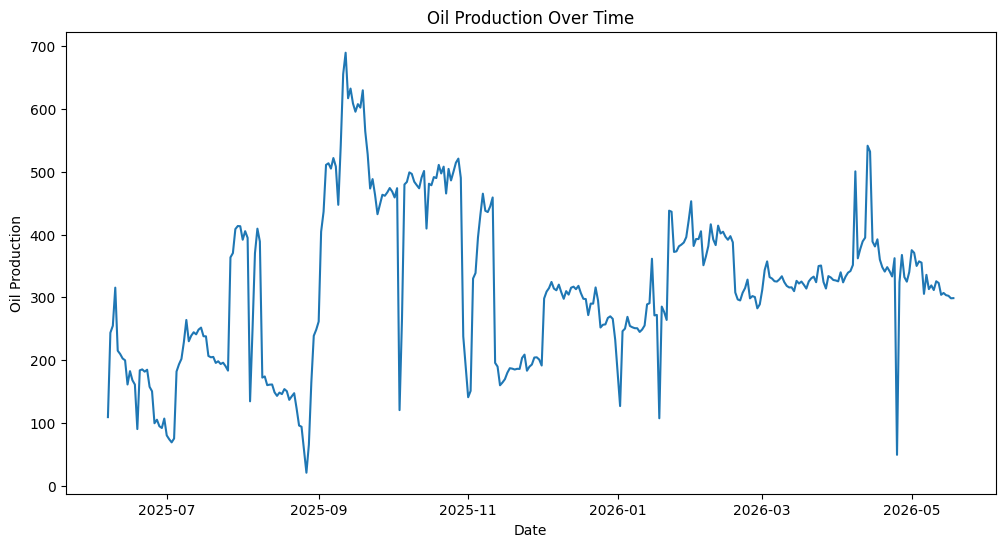

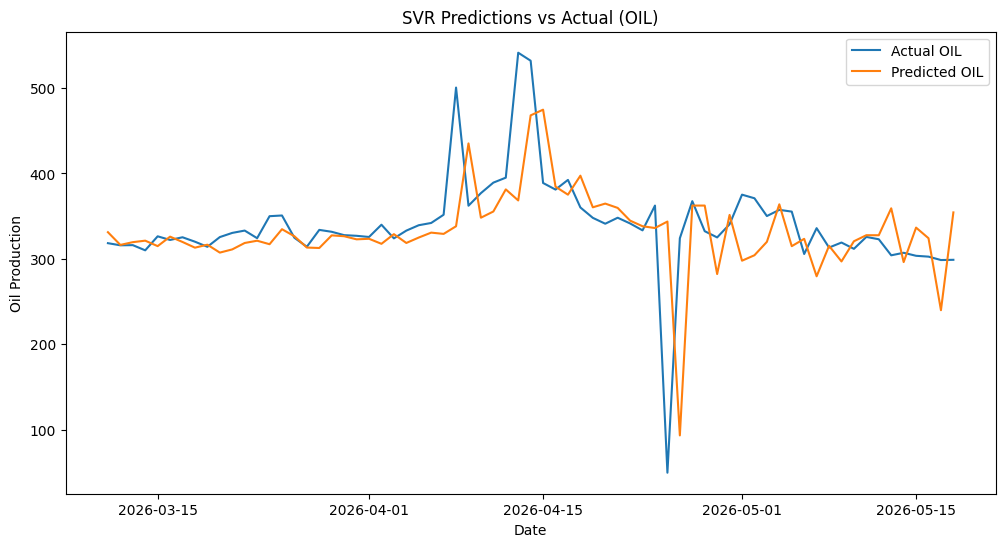

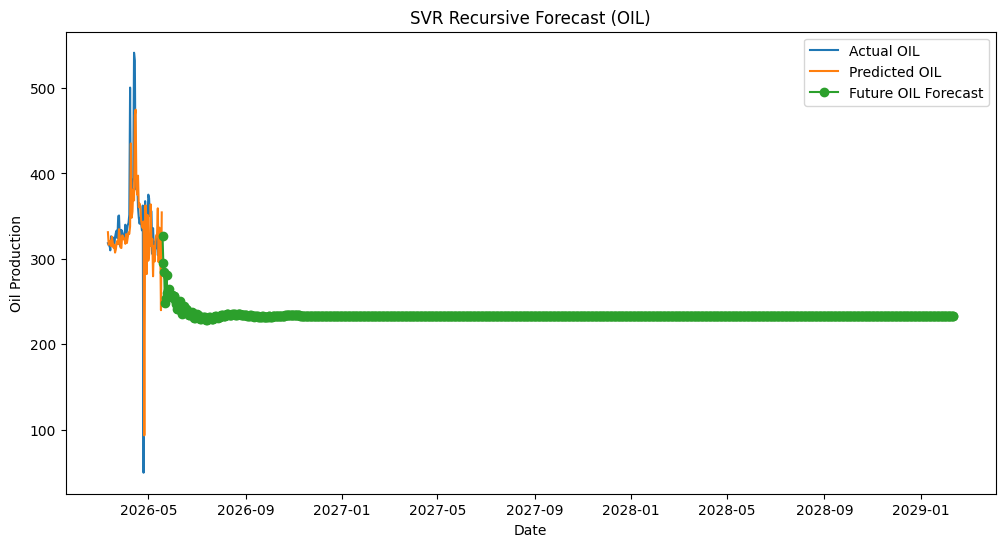

In [61]:
def main():
    # Load and visualize data
    path = "/home/rian/python_project/myvenv/dca_ml/data/test_data.csv"
    df = load_data(path)
    df['LN_OIL'] = np.log(df['OIL'])
    visualize_data(df)

    # Split data with 80% for training and 20% for testing
    train_size = int(len(df) * 0.8)
    series = df["LN_OIL"].values

    # Create supervised features with a rolling window of 30 past values
    # (30 previous days -> predict the current/next point)
    time_steps = 30
    X_all, y_all, target_indices = create_dataset(series, time_steps=time_steps)

    train_mask = target_indices < train_size
    test_mask = target_indices >= train_size

    X_train, y_train = X_all[train_mask], y_all[train_mask]
    X_test, y_test = X_all[test_mask], y_all[test_mask]
    test_dates = df["TEST_DATE"].iloc[target_indices[test_mask]]

    # Train SVR model in log space
    model = make_pipeline(MinMaxScaler(), SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1))
    model.fit(X_train, y_train)

    # Predict on test set (log space)
    y_pred = model.predict(X_test)

    # Convert back from LN_OIL to OIL for interpretation/plotting
    y_test_oil = np.exp(y_test)
    y_pred_oil = np.exp(y_pred)

    plt.figure(figsize=(12, 6))
    plt.plot(test_dates, y_test_oil, label="Actual OIL")
    plt.plot(test_dates, y_pred_oil, label="Predicted OIL")
    plt.title("SVR Predictions vs Actual (OIL)")
    plt.xlabel("Date")
    plt.ylabel("Oil Production")
    plt.legend()
    plt.show()

    # Recursive forecasting in log space with rolling 30-step window
    # Step k uses [last 30 known/predicted values] -> predict step k+1
    future_steps = 1000
    future_predictions_ln = []
    history = series[-time_steps:].tolist()

    for _ in range(future_steps):
        current_input = np.array(history[-time_steps:]).reshape(1, -1)
        future_pred_ln = model.predict(current_input)[0]
        future_predictions_ln.append(future_pred_ln)
        history.append(future_pred_ln)

    future_predictions_oil = np.exp(np.array(future_predictions_ln))

    freq = pd.infer_freq(df["TEST_DATE"]) or 'D'
    future_dates = pd.date_range(
        start=df["TEST_DATE"].iloc[-1],
        periods=future_steps + 1,
        freq=freq
    )[1:]

    plt.figure(figsize=(12, 6))
    plt.plot(test_dates, y_test_oil, label="Actual OIL")
    plt.plot(test_dates, y_pred_oil, label="Predicted OIL")
    plt.plot(future_dates, future_predictions_oil, label="Future OIL Forecast", marker='o')
    plt.title("SVR Recursive Forecast (OIL)")
    plt.xlabel("Date")
    plt.ylabel("Oil Production")
    plt.legend()
    plt.show()

if __name__ == "__main__":
    main()